## Scraping Data

In [48]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns
import numpy as np
import re

def get_api_key(filename='youtube_api_key.txt'):
    try:
        with open(filename, 'r') as file:
            return file.read().strip()
    except FileNotFoundError:
        print(f"Error: '{filename}' not found.")
        return None 

def get_duration_seconds(duration_str):
    """Converts ISO 8601 duration (PT#H#M#S) to total seconds."""
    hours = re.search(r'(\d+)H', duration_str)
    minutes = re.search(r'(\d+)M', duration_str)
    seconds = re.search(r'(\d+)S', duration_str)
    
    total_seconds = 0
    if hours: total_seconds += int(hours.group(1)) * 3600
    if minutes: total_seconds += int(minutes.group(1)) * 60
    if seconds: total_seconds += int(seconds.group(1))
    return total_seconds

def get_dislike_data(video_ids):
    results = []
    print(f"Fetching video data for {len(video_ids)} videos...")
    for v_id in video_ids:
        try:
            ryd_url = f"https://returnyoutubedislikeapi.com/votes?videoId={v_id}"
            res = requests.get(ryd_url, timeout=10).json()
            results.append({
                'id': v_id,
                'Dislikes': res.get('dislikes', 0)
            })
            time.sleep(0.05) 
        except:
            results.append({'id': v_id, 'Dislikes': 0})
            continue
    return pd.DataFrame(results)

def get_video_stats(api_key, channel_id, channel_name):
    ch_url = f"https://www.googleapis.com/youtube/v3/channels?part=contentDetails&id={channel_id}&key={api_key}"
    ch_data = requests.get(ch_url).json()
    
    if 'items' not in ch_data:
        print("Channel not found.")
        return pd.DataFrame()
        
    uploads_id = ch_data['items'][0]['contentDetails']['relatedPlaylists']['uploads']
    video_metadata = []
    next_page = None
    reached_cutoff = False

    print("Fetching all video metadata (No duration restrictions)...")
    while not reached_cutoff:
        pl_url = f"https://www.googleapis.com/youtube/v3/playlistItems?part=snippet,contentDetails&playlistId={uploads_id}&maxResults=50&pageToken={next_page if next_page else ''}&key={api_key}"
        pl_res = requests.get(pl_url).json()
        
        items = pl_res.get('items', [])
        if not items: break

        v_ids = [item['contentDetails']['videoId'] for item in items]
        
        stats_url = f"https://www.googleapis.com/youtube/v3/videos?part=snippet,statistics,contentDetails&id={','.join(v_ids)}&key={api_key}"
        stats_res = requests.get(stats_url).json()

        for video in stats_res.get('items', []):
            # Duration logic kept for data enrichment, but filtering removed
            iso_duration = video['contentDetails'].get('duration', '')
            duration_sec = get_duration_seconds(iso_duration)
            
            pub_date = pd.to_datetime(video['snippet']['publishedAt'])
            if pub_date.year < 2017:
                reached_cutoff = True
                break 
            
            stats = video.get('statistics', {})
            video_metadata.append({
                'YouTuber_Name': channel_name,
                'id': video['id'],
                'Title': video['snippet']['title'],
                'Date': pub_date,
                'Duration_Seconds': duration_sec, # Now includes all lengths
                'Views': int(stats.get('viewCount', 0)),
                'Likes': int(stats.get('likeCount', 0)),
                'Comments': int(stats.get('commentCount', 0))
            })
        
        if reached_cutoff: break
        next_page = pl_res.get('nextPageToken')
        if not next_page: break

    df_meta = pd.DataFrame(video_metadata)
    if df_meta.empty: return pd.DataFrame()
        
    df_dislikes = get_dislike_data(df_meta['id'].tolist())
    df_merged = pd.merge(df_meta, df_dislikes, on='id')

    df_merged = df_merged.drop(columns=['id'])

    if not df_merged.empty:
        df_merged['Like_to_Dislike_Ratio'] = df_merged['Likes'] / df_merged['Dislikes'].replace(0, np.nan)
        df_merged['Dislike_to_Like_Ratio'] = df_merged['Dislikes'] / df_merged['Likes'].replace(0, np.nan)
        df_merged['Engagement_Ratio'] = (
            (df_merged['Likes'] + df_merged['Dislikes'] + df_merged['Comments']) / 
            df_merged['Views'].replace(0, np.nan)
        ) * 100
    
    return df_merged

def get_channel_id(api_key, query):
    search_url = f"https://www.googleapis.com/youtube/v3/search?part=snippet&q={query}&type=channel&maxResults=1&key={api_key}"
    try:
        response = requests.get(search_url).json()
        items = response.get('items', [])
        if items:
            return items[0]['snippet']['channelId'], items[0]['snippet']['channelTitle']
        return None, None
    except Exception as e:
        print(f"Error: {e}")
        return None, None

# --- Execution ---
API_KEY = get_api_key()
YOUTUBER_INPUT = input("Please enter the YouTuber's name: ")

if API_KEY:
    CHANNEL_ID, ACTUAL_NAME = get_channel_id(API_KEY, YOUTUBER_INPUT)
    if CHANNEL_ID:
        df = get_video_stats(API_KEY, CHANNEL_ID, ACTUAL_NAME)
        if not df.empty:
            df['Date'] = pd.to_datetime(df['Date'], utc=True)
            df = df.sort_values('Date')
            
            # Save the clean CSV
            filename = f'Data_{ACTUAL_NAME.replace(" ", "_")}.csv'
            df.to_csv(filename, index=False)
            print(f"Success! Final dataset saved to {filename}")

            # Plotting
            fig, ax1 = plt.subplots(figsize=(18, 10))
            ax1.bar(df['Date'], df['Likes'], color='LimeGreen', label='Likes', alpha=0.6, width=10)
            ax1.bar(df['Date'], df['Dislikes'], bottom=df['Likes'], color='crimson', label='Dislikes', alpha=0.6, width=10)
            ax1.set_ylabel("Engagement (Likes + Dislikes)", fontsize=12)
            plt.title(f"{ACTUAL_NAME}: Data (2018-Present)", fontsize=16)
            plt.legend()
            plt.savefig(f"Analysis_{ACTUAL_NAME.replace(' ', '_')}.png")
            plt.show()
        else:
            print("No data found for the specified criteria.")


KeyboardInterrupt



## Scraping Data (Excluding Streams and Shorts)

Please enter the YouTuber's name:  That Vegan Teacher


Fetching video metadata and applying duration filters...
Fetching ReturnYouTubeDislike data for 2994 videos...
Success! Final dataset saved to Data_That_Vegan_Teacher.csv


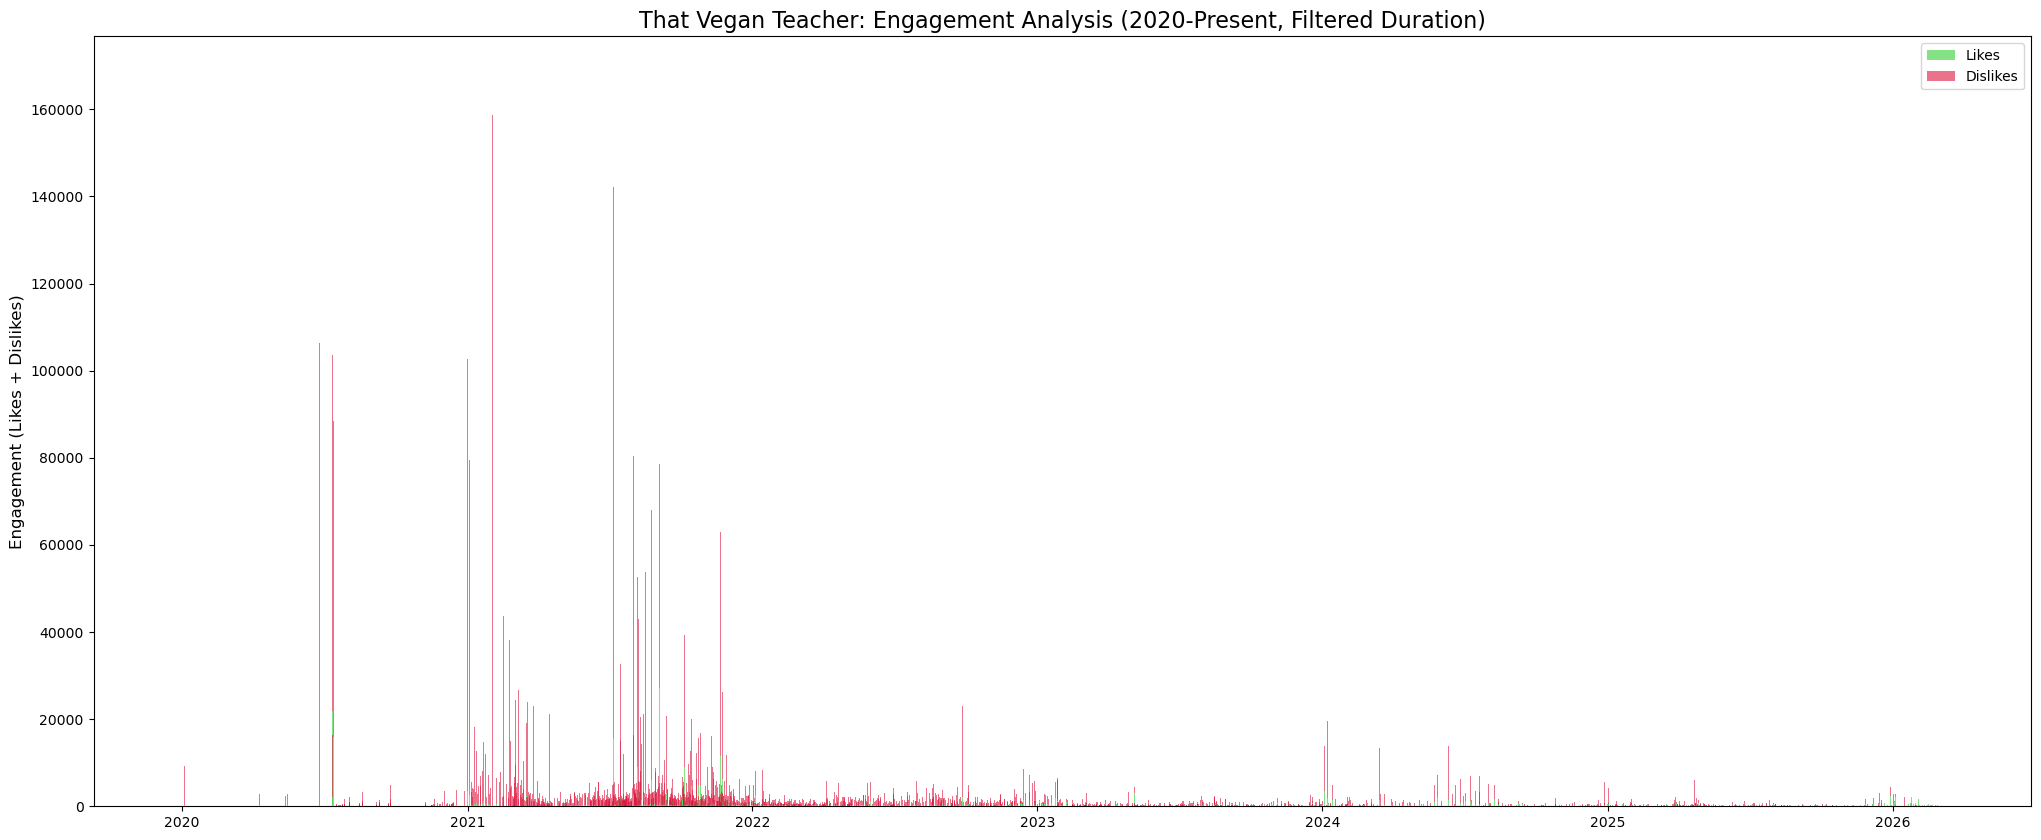

In [49]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns
import numpy as np
import re

def get_api_key(filename='youtube_api_key.txt'):
    try:
        with open(filename, 'r') as file:
            return file.read().strip()
    except FileNotFoundError:
        print(f"Error: '{filename}' not found.")
        return None 

def get_duration_seconds(duration_str):
    """Converts ISO 8601 duration (PT#H#M#S) to total seconds."""
    hours = re.search(r'(\d+)H', duration_str)
    minutes = re.search(r'(\d+)M', duration_str)
    seconds = re.search(r'(\d+)S', duration_str)
    
    total_seconds = 0
    if hours: total_seconds += int(hours.group(1)) * 3600
    if minutes: total_seconds += int(minutes.group(1)) * 60
    if seconds: total_seconds += int(seconds.group(1))
    return total_seconds

def get_dislike_data(video_ids):
    results = []
    print(f"Fetching ReturnYouTubeDislike data for {len(video_ids)} videos...")
    for v_id in video_ids:
        try:
            ryd_url = f"https://returnyoutubedislikeapi.com/votes?videoId={v_id}"
            res = requests.get(ryd_url, timeout=10).json()
            results.append({
                'id': v_id,
                'Dislikes': res.get('dislikes', 0)
            })
            time.sleep(0.05) 
        except:
            results.append({'id': v_id, 'Dislikes': 0})
            continue
    return pd.DataFrame(results)

def get_video_stats(api_key, channel_id, channel_name):
    ch_url = f"https://www.googleapis.com/youtube/v3/channels?part=contentDetails&id={channel_id}&key={api_key}"
    ch_data = requests.get(ch_url).json()
    
    if 'items' not in ch_data:
        print("Channel not found.")
        return pd.DataFrame()
        
    uploads_id = ch_data['items'][0]['contentDetails']['relatedPlaylists']['uploads']
    video_metadata = []
    next_page = None
    reached_cutoff = False

    print("Fetching video metadata and applying duration filters...")
    while not reached_cutoff:
        pl_url = f"https://www.googleapis.com/youtube/v3/playlistItems?part=snippet,contentDetails&playlistId={uploads_id}&maxResults=50&pageToken={next_page if next_page else ''}&key={api_key}"
        pl_res = requests.get(pl_url).json()
        
        items = pl_res.get('items', [])
        if not items: break

        v_ids = [item['contentDetails']['videoId'] for item in items]
        
        # We add 'contentDetails' to the part parameter to get video durations
        stats_url = f"https://www.googleapis.com/youtube/v3/videos?part=snippet,statistics,contentDetails&id={','.join(v_ids)}&key={api_key}"
        stats_res = requests.get(stats_url).json()

        for video in stats_res.get('items', []):
            # --- DURATION FILTERING ---
            iso_duration = video['contentDetails'].get('duration', '')
            duration_sec = get_duration_seconds(iso_duration)
            
            # Exclude videos > 1 hour (3600s) OR < 1 minute (60s)
            if duration_sec > 3600 or duration_sec < 60:
                continue 
            
            pub_date = pd.to_datetime(video['snippet']['publishedAt'])
            if pub_date.year < 2020:
                reached_cutoff = True
                break 
            
            stats = video.get('statistics', {})
            video_metadata.append({
                'YouTuber_Name': channel_name,
                'id': video['id'],
                'Title': video['snippet']['title'],
                'Date': pub_date,
                'Views': int(stats.get('viewCount', 0)),
                'Likes': int(stats.get('likeCount', 0)),
                'Comments': int(stats.get('commentCount', 0))
            })
        
        if reached_cutoff: break
        next_page = pl_res.get('nextPageToken')
        if not next_page: break

    df_meta = pd.DataFrame(video_metadata)
    if df_meta.empty: return pd.DataFrame()
        
    df_dislikes = get_dislike_data(df_meta['id'].tolist())
    df_merged = pd.merge(df_meta, df_dislikes, on='id')

    df_merged = df_merged.drop(columns=['id'])
    df_merged = df_merged[~df_merged['Title'].str.contains('Storyboard vs Animation', na=False, case=False)]

    if not df_merged.empty:
        df_merged['Like_to_Dislike_Ratio'] = df_merged['Likes'] / df_merged['Dislikes'].replace(0, np.nan)
        df_merged['Dislike_to_Like_Ratio'] = df_merged['Dislikes'] / df_merged['Likes'].replace(0, np.nan)
        df_merged['Engagement_Ratio'] = (
            (df_merged['Likes'] + df_merged['Dislikes'] + df_merged['Comments']) / 
            df_merged['Views'].replace(0, np.nan)
        ) * 100
    
    return df_merged

def get_channel_id(api_key, query):
    search_url = f"https://www.googleapis.com/youtube/v3/search?part=snippet&q={query}&type=channel&maxResults=1&key={api_key}"
    try:
        response = requests.get(search_url).json()
        items = response.get('items', [])
        if items:
            return items[0]['snippet']['channelId'], items[0]['snippet']['channelTitle']
        return None, None
    except Exception as e:
        print(f"Error: {e}")
        return None, None

# --- Execution ---
API_KEY = get_api_key()
YOUTUBER_INPUT = input("Please enter the YouTuber's name: ")

if API_KEY:
    CHANNEL_ID, ACTUAL_NAME = get_channel_id(API_KEY, YOUTUBER_INPUT)
    if CHANNEL_ID:
        df = get_video_stats(API_KEY, CHANNEL_ID, ACTUAL_NAME)
        if not df.empty:
            df['Date'] = pd.to_datetime(df['Date'], utc=True)
            df = df.sort_values('Date')
            
            filename = f'Data_{ACTUAL_NAME.replace(" ", "_")}.csv'
            df.to_csv(filename, index=False)
            print(f"Success! Final dataset saved to {filename}")

            # Plotting
            fig, ax1 = plt.subplots(figsize=(25, 10))
            ax1.bar(df['Date'], df['Likes'], color='LimeGreen', label='Likes', alpha=0.6)
            ax1.bar(df['Date'], df['Dislikes'], bottom=df['Likes'], color='crimson', label='Dislikes', alpha=0.6)
            ax1.set_ylabel("Engagement (Likes + Dislikes)", fontsize=12)
            plt.title(f"{ACTUAL_NAME}: Engagement Analysis (2020-Present, Filtered Duration)", fontsize=16)
            plt.legend()
            plt.savefig(f"Analysis_{ACTUAL_NAME.replace(' ', '_')}.png")
            plt.show()
        else:
            print("No data found for the specified criteria.")

## Removing Values of 0 and Excess Shorts

In [3]:
import pandas as pd

# 1. Load your dataset
df = pd.read_csv('Data_That_Vegan_Teacher.csv')
df.isnull().sum()

YouTuber_Name            0
Title                    0
Date                     0
Views                    0
Likes                    0
Comments                 0
Dislikes                 0
Like_to_Dislike_Ratio    0
Dislike_to_Like_Ratio    0
Engagement_Ratio         0
dtype: int64

In [4]:
df = pd.read_csv('Data_Ben_Shapiro.csv')

# 2. Define the columns you want to check
cols_to_check = ['Views', 'Likes', 'Dislikes']

# 3. Keep rows where ALL of the specified columns are NOT 0
# This effectively removes any row that has a 0 in ANY of those columns
df_cleaned = df[(df[cols_to_check] != 0).all(axis=1)]

# 4. Save the "cleaned" data to a NEW file for safety first
df_cleaned.to_csv('Data_That_Vegan_Teacher.csv', index=False)

# 5. Summary
print(f"Original rows: {len(df)}")
print(f"Rows removed: {len(df) - len(df_cleaned)}")
print(f"Rows remaining: {len(df_cleaned)}")

Original rows: 4950
Rows removed: 0
Rows remaining: 4950


## Plotting

Please enter the name of the CSV file to plot (e.g., Data_MrBeast.csv):  Data_JaidenAnimations.csv


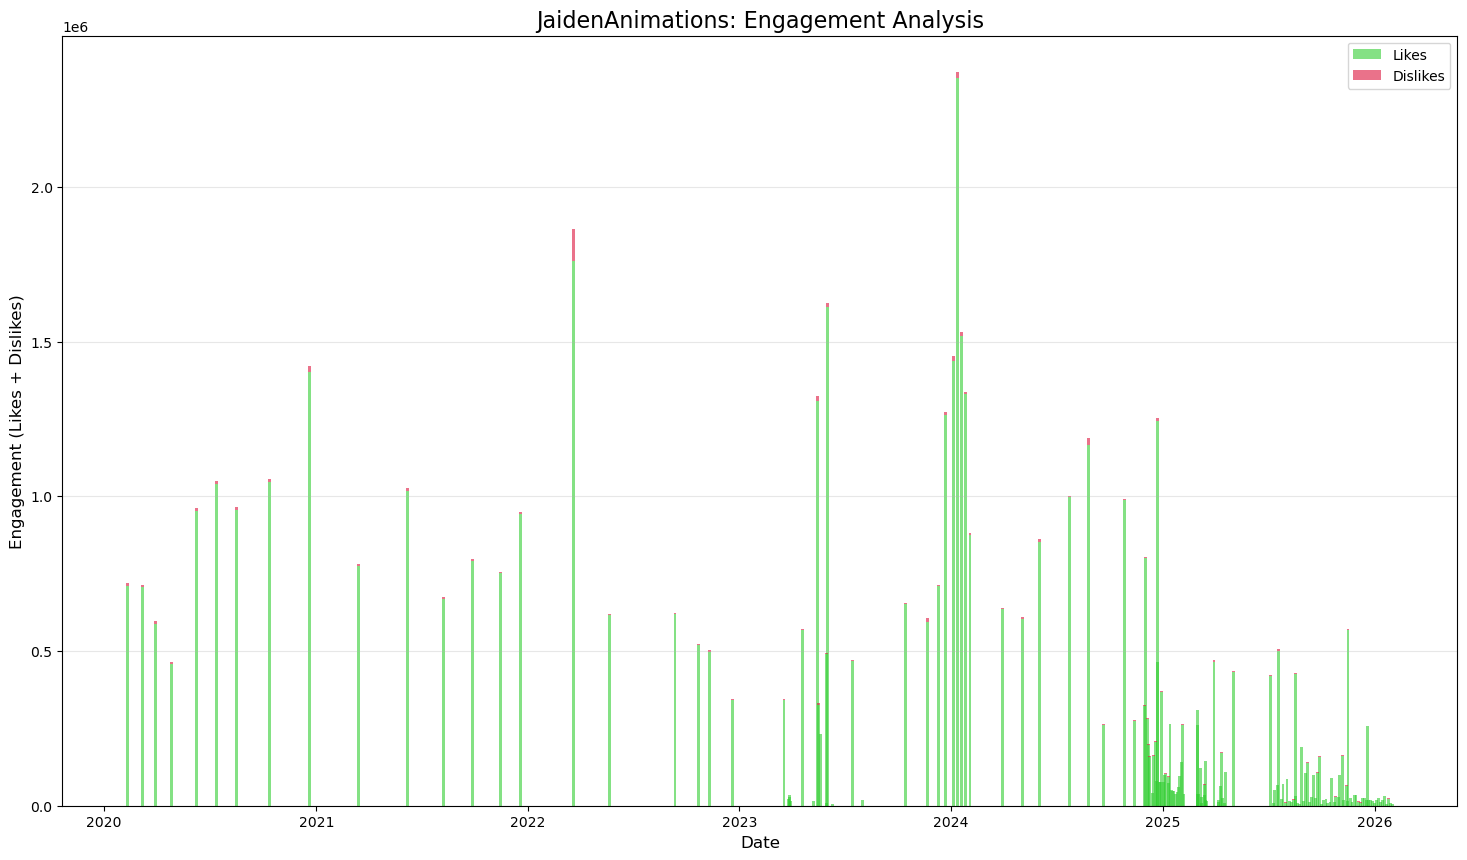

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Ask for the CSV file
csv_filename = input("Please enter the name of the CSV file to plot (e.g., Data_MrBeast.csv): ")

try:
    # 2. Load the dataset
    df = pd.read_csv(csv_filename)
    
    # 3. Clean and Sort
    df['Date'] = pd.to_datetime(df['Date'], utc=True)
    df = df.sort_values('Date')
    
    # Extract the name from the column
    actual_name = df['YouTuber_Name'].iloc[0]

    # 4. Plotting
    fig, ax1 = plt.subplots(figsize=(18, 10))
    
    # Bar Chart for Likes
    ax1.bar(df['Date'], df['Likes'], color='LimeGreen', label='Likes', alpha=0.6, width=5)
    
    # Stacked Bar for Dislikes
    ax1.bar(df['Date'], df['Dislikes'], bottom=df['Likes'], color='crimson', label='Dislikes', alpha=0.6, width=5)
    
    ax1.set_ylabel("Engagement (Likes + Dislikes)", fontsize=12)
    ax1.set_xlabel("Date", fontsize=12)
    plt.title(f"{actual_name}: Engagement Analysis", fontsize=16)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    # --- FIXED LINE BELOW ---
    # Changed savegrid() to savefig() and cleaned up the filename
    plt.savefig(f"Analysis_{actual_name.replace(' ', '_')}.png")
    
    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{csv_filename}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

## Predicting Future Engagement Variables

Enter the name of the CSV file to analyze:  Data_That_Vegan_Teacher.csv


Analysis complete. Plot saved as Full_Trend_Analysis_Data_That_Vegan_Teacher.png


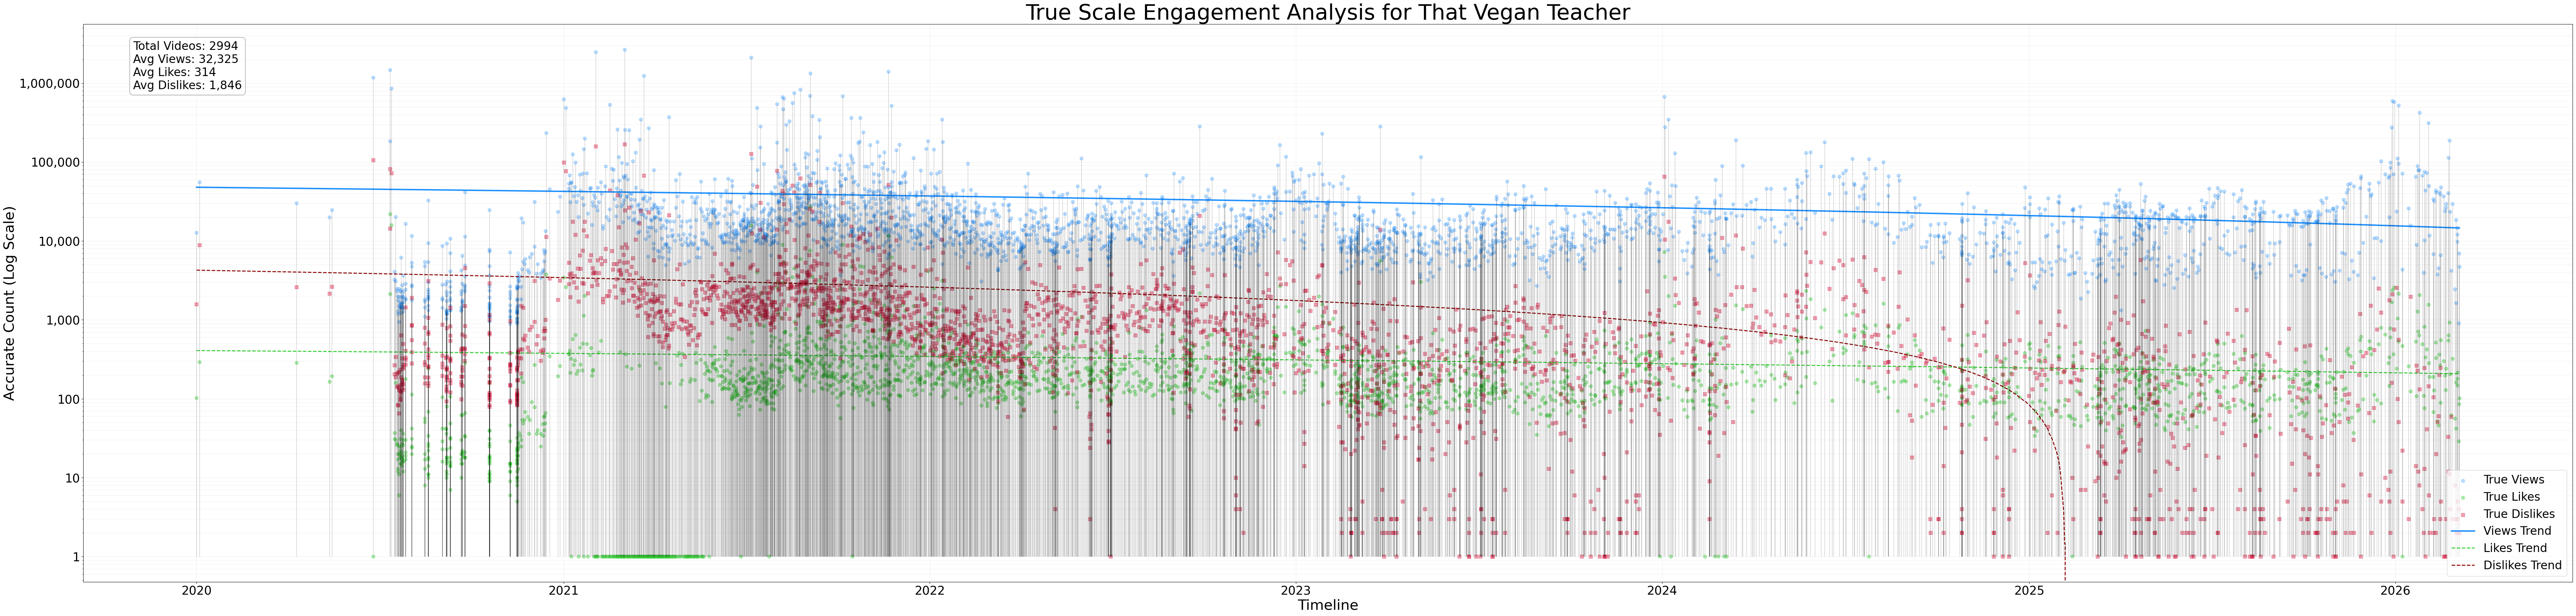

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as ticker

def analyze_youtube_csv():
    csv_path = input("Enter the name of the CSV file to analyze: ")
    
    try:
        # 1. Load and Prepare Data
        df = pd.read_csv(csv_path)
        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df = df.sort_values('Date')
        
        # Clean specific titles
        
        # Ensure no zero values for log scale (log(0) is undefined)
        df['Likes'] = df['Likes'].replace(0, 1)
        df['Dislikes'] = df['Dislikes'].replace(0, 1)
        df['Views'] = df['Views'].replace(0, 1)
        
        # 2. Linear Regression Setup
        df['Date_Ordinal'] = df['Date'].apply(lambda x: x.toordinal())
        X = df[['Date_Ordinal']].values
        
        # Train models
        model_likes = LinearRegression().fit(X, df['Likes'])
        model_dislikes = LinearRegression().fit(X, df['Dislikes'])
        model_views = LinearRegression().fit(X, df['Views'])
        
        # 3. Visualization
        plt.figure(figsize=(75, 18))
        ax = plt.gca()

        # Plotting true numbers
        plt.scatter(df['Date'], df['Views'], color='dodgerblue', alpha=0.3, label='True Views', s=50, marker='o')
        plt.scatter(df['Date'], df['Likes'], color='limegreen', alpha=0.4, label='True Likes', s=50)
        
        # --- CHANGED: Dislikes now use 's' (square) marker ---
        plt.scatter(df['Date'], df['Dislikes'], color='crimson', alpha=0.4, label='True Dislikes', s=50, marker='s')

        # Trendlines
        plt.plot(df['Date'], model_views.predict(X), color='dodgerblue', linewidth=3, label='Views Trend')
        plt.plot(df['Date'], model_likes.predict(X), color='limegreen', linewidth=2, linestyle='--', label='Likes Trend')
        plt.plot(df['Date'], model_dislikes.predict(X), color='darkred', linewidth=2, linestyle='--', label='Dislikes Trend')

        # --- LOGARITHMIC SCALE SETTINGS ---
        ax.set_yscale('log')
        
        # Formatting the labels to show full numbers
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

        ax.tick_params(axis='both', which='major', labelsize=25)
        ax.tick_params(axis='both', which='minor', labelsize=25)

        # 4. Stats and Labels
        total_videos = len(df)
        stats_text = (f"Total Videos: {total_videos}\n"
                      f"Avg Views: {df['Views'].mean():,.0f}\n"
                      f"Avg Likes: {df['Likes'].mean():,.0f}\n"
                      f"Avg Dislikes: {df['Dislikes'].mean():,.0f}")
        
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        ax.text(0.02, 0.97, stats_text, transform=ax.transAxes, fontsize=24, verticalalignment='top', bbox=props)

        youtuber = df['YouTuber_Name'].iloc[0] if 'YouTuber_Name' in df.columns else "Channel"
        plt.title(f"True Scale Engagement Analysis for {youtuber}", fontsize=45)
        plt.xlabel("Timeline", fontsize=30)
        plt.ylabel("Accurate Count (Log Scale)", fontsize=30)
        plt.legend(loc='lower right', fontsize=24)
        plt.vlines(df['Date'], ymin=1, ymax=df['Views'], color='black', alpha=0.2, linewidth=1)
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.tight_layout()
        
        clean_name = csv_path.replace('.csv', '').replace(' ', '_')
        output_filename = f"Full_Trend_Analysis_{clean_name}.png"
        plt.savefig(output_filename, dpi=300)
        print(f"Analysis complete. Plot saved as {output_filename}")
        plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    analyze_youtube_csv()

## Correlations

Enter the CSV filename (e.g., Data_MrBeast.csv):  Data_That_Vegan_Teacher.csv
Enter the YouTuber's name for the title:  That Vegan Teacher


Heatmap for That Vegan Teacher saved as 'youtuber_correlation_heatmap_That Vegan Teacher'.png'.


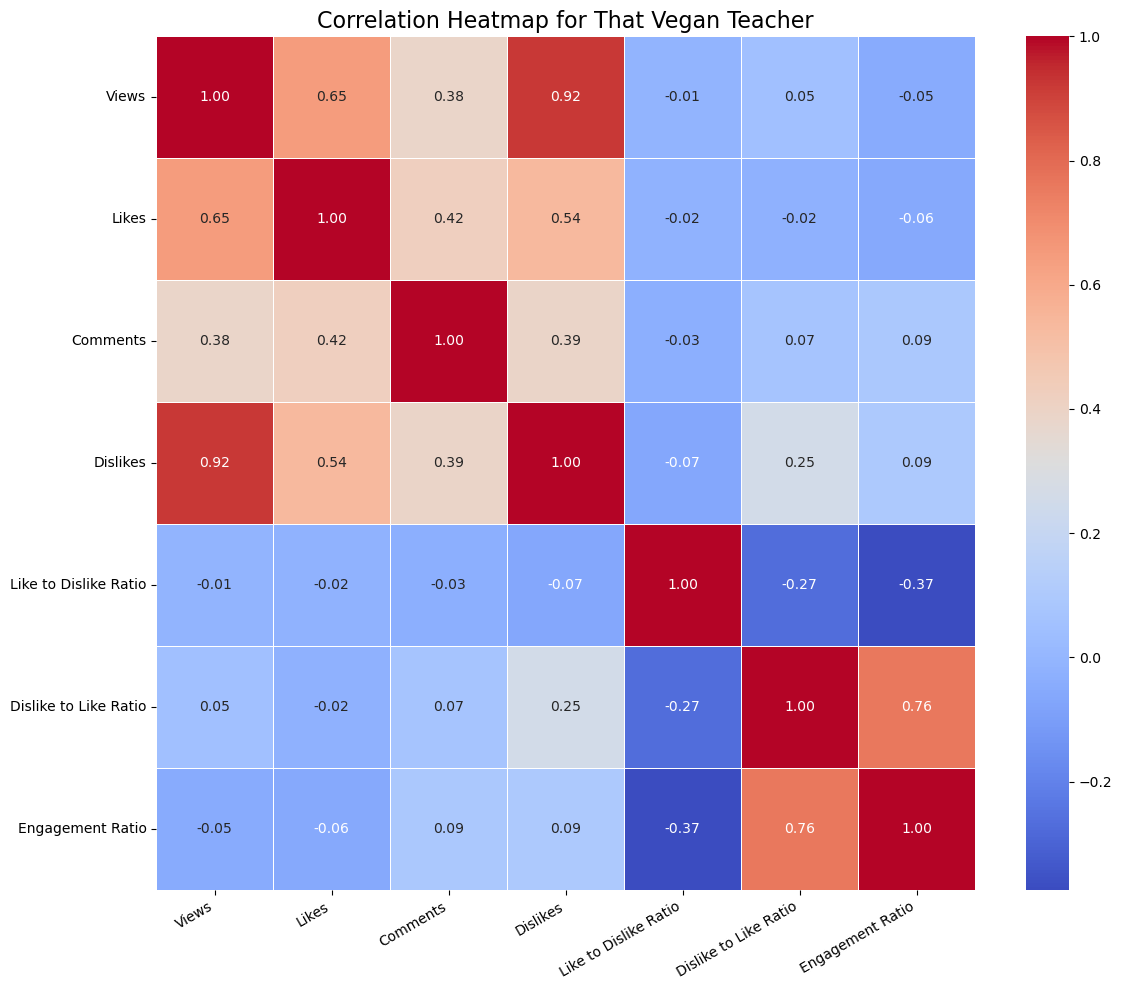

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ask the user for inputs
filename = input("Enter the CSV filename (e.g., Data_MrBeast.csv): ").strip()
youtuber_name = input("Enter the YouTuber's name for the title: ").strip()

try:
    # Load the dataset
    df = pd.read_csv(filename)

    # 2. Remove underscores in each of the column titles
    df.columns = [col.replace('_', ' ') for col in df.columns]

    # 3. Select only numerical columns for correlation calculation
    numerical_df = df.select_dtypes(include=['float64', 'int64'])

    if numerical_df.empty:
        print("No numerical data found in the file to calculate correlations.")
    else:
        # Calculate the correlation matrix
        corr_matrix = numerical_df.corr()

        # Plot the correlation heatmap
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

        # 4. Use the YouTuber's name in the title
        plt.title(f'Correlation Heatmap for {youtuber_name}', fontsize=16)
        
        # Adjust layout to prevent label truncation
        plt.xticks(rotation=30, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        # 5. Save and show the plot
        plt.savefig(f'youtuber_correlation_heatmap_{youtuber_name}.png')
        print(f"Heatmap for {youtuber_name} saved as 'youtuber_correlation_heatmap_{youtuber_name}'.png'.")
        plt.show()

except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Correlation between Dislike:Like Ratio and Engagement Ratio: -0.2704


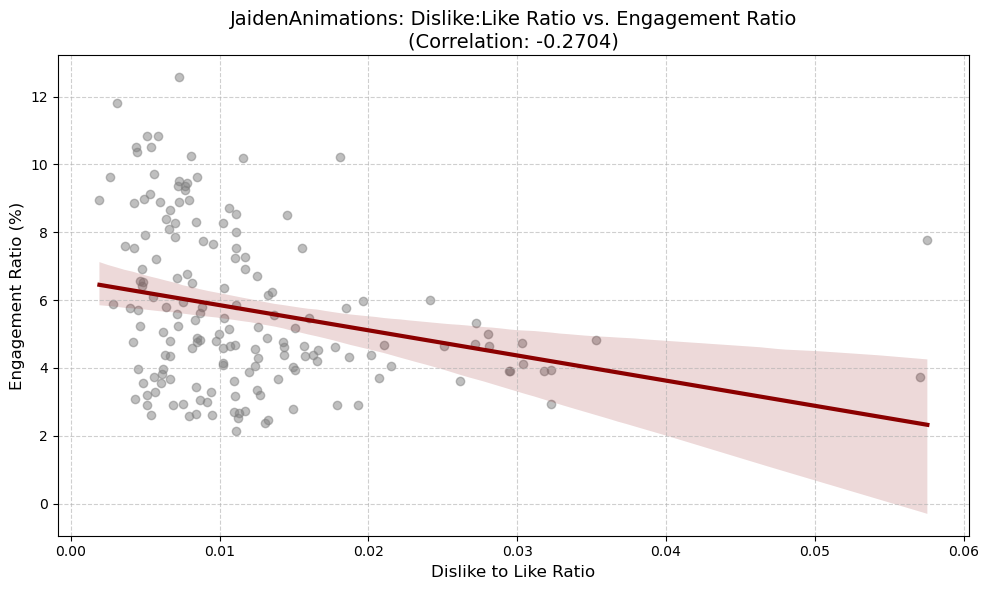

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Make sure 'Data_MandJTV.csv' is in your working directory
filename = 'Data_JaidenAnimations.csv'
df = pd.read_csv(filename)

# 2. Calculate the correlation coefficient
# This measures how closely the two variables move together
correlation = df['Dislike_to_Like_Ratio'].corr(df['Engagement_Ratio'])
print(f"Correlation between Dislike:Like Ratio and Engagement Ratio: {correlation:.4f}")

# 3. Create the Visualization
plt.figure(figsize=(10, 6))

# sns.regplot draws the scatter points AND the trend line (regression line)
sns.regplot(
    data=df, 
    x='Dislike_to_Like_Ratio', 
    y='Engagement_Ratio', 
    scatter_kws={'alpha':0.5, 'color': 'gray'}, 
    line_kws={'color':'darkred', 'lw': 3}
)

# 4. Add Titles and Labels
# We use f-strings to dynamically include the correlation in the title
plt.title(f'JaidenAnimations: Dislike:Like Ratio vs. Engagement Ratio\n(Correlation: {correlation:.4f})', fontsize=14)
plt.xlabel('Dislike to Like Ratio', fontsize=12)
plt.ylabel('Engagement Ratio (%)', fontsize=12)

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Final Layout Adjustments and Saving
plt.tight_layout()
plt.savefig('dislike_vs_engagement_JaidenAnimations.png')
plt.show()